In [2]:
from koinapy import Koina
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
import sys
from pathlib import Path
from functools import reduce
from tqdm import tqdm
import os

project_root = Path.cwd().parent

sys.path.append(str(project_root))

from make_predictions.intensity_predictions import (
    obtain_predictions_pairs,
    safe_obtain_predictions,
    safe_obtain_ccs_predictions,
    safe_obtain_rt_predictions,
)
from seq_utils.fasta_to_peptides import create_tryptic_peptides
from seq_utils.peptide import (
    remove_non_il,
    remove_ux_containing,
    switch_first_il,
    switch_random_il,
)
from metrics.get_metrics import metrics_comparison

In [3]:
# Randomly sample 2000 peptides (and corresponding switched peptides) reproducibly
sample_peps = True
sample_size = 20000

# Specify the path to your FASTA file
fasta_file = "../fasta/UP000005640_9606.fasta"

# Generate tryptic peptides
peptides = create_tryptic_peptides(fasta_file)

# Remove non-I/L amino acids
peptides = remove_non_il(peptides)
peptides = remove_ux_containing(peptides)
peptides = np.array(peptides)

if sample_peps:
    rng = np.random.default_rng(42)
    n_peptides = len(peptides)
    indices = rng.choice(n_peptides, size=sample_size, replace=False)
    peptides = peptides[indices]

# Create correct, switched pairs
peptides_switched = np.array([switch_random_il(peptide) for peptide in peptides])

In [4]:
peptides_switch_predictions_f = "../temp_data/peptides_switch_predictions.csv"
peptides_predictions_f = "../temp_data/peptides_predictions.csv"

batch_size = 5000
peptides_switch_predictions_list = []
peptides_predictions_list = []


if os.path.exists(peptides_switch_predictions_f) and os.path.exists(
    peptides_predictions_f
) and False:
    peptides_switch_predictions = pd.read_csv(peptides_switch_predictions_f)
    peptides_predictions = pd.read_csv(peptides_predictions_f)
else:
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch_switched = peptides_switched[i : i + batch_size]
        batch = peptides[i : i + batch_size]

        print(batch_switched)

        peptides_switch_predictions_list.append(
            safe_obtain_predictions(batch_switched, switched=False)
        )
        peptides_predictions_list.append(safe_obtain_predictions(batch, switched=True))

    peptides_switch_predictions = pd.concat(
        peptides_switch_predictions_list, ignore_index=True
    )
    peptides_predictions = pd.concat(peptides_predictions_list, ignore_index=True)

    peptides_switch_predictions.to_csv(
        peptides_switch_predictions_f,
        index=False,
    )
    peptides_predictions.to_csv(peptides_predictions_f, index=False)

  0%|          | 0/4 [00:00<?, ?it/s]

['LHFCLVLLLILVVPAAWGCGPGR' 'QLGSPTADIA' 'NNNGLEIGCVVDAASGLITFIANGK' ...
 'GNIPAESYTFFIDILLDTLR' 'LTSFVDMVR' 'ENQLSVR']
                peptide_sequences  precursor_charges  collision_energies  \
0         LHFCLVLLLILVVPAAWGCGPGR                  2                  28   
1                      QLGSPTADIA                  2                  28   
2       NNNGLEIGCVVDAASGLITFIANGK                  2                  28   
3     YALVFGLNTFIALVIQTIMTVIVVDQR                  2                  28   
4                CMLFSSGTVQITTTSR                  2                  28   
...                           ...                ...                 ...   
4995                     QESIMPWK                  2                  28   
4996                    INGNCTGLK                  2                  28   
4997         GNIPAESYTFFIDILLDTLR                  2                  28   
4998                    LTSFVDMVR                  2                  28   
4999                      ENQLSVR            

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

                peptide_sequences  precursor_charges  collision_energies  \
0         LHFCLVLLLLLVVPAAWGCGPGR                  2                  28   
1                      QLGSPTADLA                  2                  28   
2       NNNGLEIGCVVDAASGLLTFIANGK                  2                  28   
3     YALVFGINTFIALVIQTIMTVIVVDQR                  2                  28   
4                CMLFSSGTVQLTTTSR                  2                  28   
...                           ...                ...                 ...   
4995                     QESLMPWK                  2                  28   
4996                    INGNCTGIK                  2                  28   
4997         GNIPAESYTFFIDILLDTIR                  2                  28   
4998                    ITSFVDMVR                  2                  28   
4999                      ENQISVR                  2                  28   

     instrument_types fragmentation_types  
0               LUMOS                 HCD  

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

...

['GLAGEDTK' 'MAATDIER' 'QQSPVNPDPVAIDAHR' ... 'LEIGDVQALSLWQK'
 'QLALGVNEVTR' 'NYLQWITER']
                   peptide_sequences  precursor_charges  collision_energies  \
0                           GLAGEDTK                  2                  28   
1                           MAATDIER                  2                  28   
2                   QQSPVNPDPVAIDAHR                  2                  28   
3                        NNLTIDQPQDK                  2                  28   
4      TELYFISPQENRPSLFGMPLIVPCTVHTR                  2                  28   
...                              ...                ...                 ...   
4995            LLGVAHLFDIDPETPANGYR                  2                  28   
4996  LLLYDGDLDEAVGMLLEGCHAEFDGNTALK                  2                  28   
4997                  LEIGDVQALSLWQK                  2                  28   
4998                     QLALGVNEVTR                  2                  28   
4999                       NYLQWITER    

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

                   peptide_sequences  precursor_charges  collision_energies  \
0                           GIAGEDTK                  2                  28   
1                           MAATDLER                  2                  28   
2                   QQSPVNPDPVALDAHR                  2                  28   
3                        NNLTLDQPQDK                  2                  28   
4      TELYFLSPQENRPSLFGMPLIVPCTVHTR                  2                  28   
...                              ...                ...                 ...   
4995            LLGVAHLFDLDPETPANGYR                  2                  28   
4996  LLLYDGDLDEAVGMLLEGCHAEFDGNTAIK                  2                  28   
4997                  LELGDVQALSLWQK                  2                  28   
4998                     QLAIGVNEVTR                  2                  28   
4999                       NYLQWLTER                  2                  28   

     instrument_types fragmentation_types  
0      

Prosit_2020_intensity_HCD::   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:13<00:00,  3.41s/it]


In [5]:
peptides_switch_predictions_f_ccs = "../temp_data/peptides_switch_predictions_ccs.csv"
peptides_predictions_f_ccs = "../temp_data/peptides_predictions_ccs.csv"

batch_size = 5000
peptides_switch_predictions_list_ccs = []
peptides_predictions_list_ccs = []


if (
    os.path.exists(peptides_switch_predictions_f_ccs)
    and os.path.exists(peptides_predictions_f_ccs)
    and False
):
    peptides_switch_predictions_ccs = pd.read_csv(peptides_switch_predictions_f_ccs)
    peptides_predictions_ccs = pd.read_csv(peptides_predictions_f_ccs)
else:
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch_switched = peptides_switched[i : i + batch_size]
        batch = peptides[i : i + batch_size]

        print(batch_switched)

        peptides_switch_predictions_list_ccs.append(
            safe_obtain_ccs_predictions(batch_switched, switched=False)
        )
        peptides_predictions_list_ccs.append(
            safe_obtain_ccs_predictions(batch, switched=True)
        )

    peptides_switch_predictions_ccs = pd.concat(
        peptides_switch_predictions_list_ccs, ignore_index=True
    )
    peptides_predictions_ccs = pd.concat(peptides_predictions_list_ccs, ignore_index=True)

    peptides_switch_predictions_ccs.to_csv(
        peptides_switch_predictions_f_ccs,
        index=False,
    )
    peptides_predictions_ccs.to_csv(peptides_predictions_f_ccs, index=False)

  0%|          | 0/4 [00:00<?, ?it/s]

['LHFCLVLLLILVVPAAWGCGPGR' 'QLGSPTADIA' 'NNNGLEIGCVVDAASGLITFIANGK' ...
 'GNIPAESYTFFIDILLDTLR' 'LTSFVDMVR' 'ENQLSVR']
CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

...

['GLAGEDTK' 'MAATDIER' 'QQSPVNPDPVAIDAHR' ... 'LEIGDVQALSLWQK'
 'QLALGVNEVTR' 'NYLQWITER']
CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:05<00:00,  1.47s/it]


In [6]:
# Map switched sequences back to original peptides (used by all prediction types)
switched_to_orig = dict(zip(peptides_switched, peptides))

# Create unique ID for each peptide sequence + charge combination (CCS predictions)
peptides_predictions_ccs["seq_charge"] = (
    peptides_predictions_ccs["peptide_sequences"]
    + "/"
    + peptides_predictions_ccs["precursor_charges"].astype(str)
)
unique_combinations_ccs = peptides_predictions_ccs["seq_charge"].unique()
seq_charge_to_id_ccs = {combo: i for i, combo in enumerate(unique_combinations_ccs)}

peptides_predictions_ccs["ID"] = peptides_predictions_ccs["seq_charge"].map(seq_charge_to_id_ccs)

# Create the same ID column for switched CCS predictions based on original peptide mapping
peptides_switch_predictions_ccs["seq_charge"] = (
    peptides_switch_predictions_ccs["peptide_sequences"]
    + "/"
    + peptides_switch_predictions_ccs["precursor_charges"].astype(str)
)

# Map switched sequences back to original IDs (switched peptide -> original peptide -> ID)
peptides_switch_predictions_ccs["orig_seq_charge"] = peptides_switch_predictions_ccs.apply(
    lambda row: switched_to_orig.get(row["peptide_sequences"], row["peptide_sequences"])
    + "/"
    + str(row["precursor_charges"]),
    axis=1,
)
peptides_switch_predictions_ccs["ID"] = peptides_switch_predictions_ccs["orig_seq_charge"].map(seq_charge_to_id_ccs)

print(f"Unique peptide+charge combinations (CCS): {len(unique_combinations_ccs)}")
print(f"peptides_predictions_ccs IDs: {peptides_predictions_ccs['ID'].nunique()}")
print(f"peptides_switch_predictions_ccs IDs: {peptides_switch_predictions_ccs['ID'].nunique()}")

Unique peptide+charge combinations (CCS): 20000
peptides_predictions_ccs IDs: 20000
peptides_switch_predictions_ccs IDs: 19999


In [7]:
peptides_switch_predictions_f_rt = "../temp_data/peptides_switch_predictions_rt.csv"
peptides_predictions_f_rt = "../temp_data/peptides_predictions_rt.csv"

batch_size = 5000
peptides_switch_predictions_list_rt = []
peptides_predictions_list_rt = []

if (
    os.path.exists(peptides_switch_predictions_f_rt)
    and os.path.exists(peptides_predictions_f_rt)
    and False
):
    peptides_switch_predictions_rt = pd.read_csv(peptides_switch_predictions_f_rt)
    peptides_predictions_rt = pd.read_csv(peptides_predictions_f_rt)
else:
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch_switched = peptides_switched[i : i + batch_size]
        batch = peptides[i : i + batch_size]

        print(batch_switched)

        peptides_switch_predictions_list_rt.append(
            safe_obtain_rt_predictions(batch_switched, switched=False, model="Deeplc_hela_hf")
        )
        peptides_predictions_list_rt.append(
            safe_obtain_rt_predictions(batch, switched=True, model="Deeplc_hela_hf")
        )

    peptides_switch_predictions_rt = pd.concat(
        peptides_switch_predictions_list_rt, ignore_index=True
    )
    peptides_predictions_rt = pd.concat(peptides_predictions_list_rt, ignore_index=True)

    peptides_switch_predictions_rt.to_csv(
        peptides_switch_predictions_f_rt,
        index=False,
    )
    peptides_predictions_rt.to_csv(peptides_predictions_f_rt, index=False)

  0%|          | 0/4 [00:00<?, ?it/s]

['LHFCLVLLLILVVPAAWGCGPGR' 'QLGSPTADIA' 'NNNGLEIGCVVDAASGLITFIANGK' ...
 'GNIPAESYTFFIDILLDTLR' 'LTSFVDMVR' 'ENQLSVR']
RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

...

['GLAGEDTK' 'MAATDIER' 'QQSPVNPDPVAIDAHR' ... 'LEIGDVQALSLWQK'
 'QLALGVNEVTR' 'NYLQWITER']
RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

RT prediction input shape: (5000, 1)


Deeplc_hela_hf::   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:05<00:00,  1.49s/it]


In [8]:
peptides_predictions_rt

,peptide_sequences,irt,non_switched
0,LHFCLVLLLLLVVPAAWGCGPGR,9.214069,True
1,QLGSPTADLA,5.300016,True
2,NNNGLEIGCVVDAASGLLTFIANGK,9.949211,True
3,YALVFGINTFIALVIQTIMTVIVVDQR,8.688252,True
4,CMLFSSGTVQLTTTSR,8.025587,True
...,...,...,...
19995,LLGVAHLFDLDPETPANGYR,9.183867,True
19996,LLLYDGDLDEAVGMLLEGCHAEFDGNTAIK,9.934738,True
19997,LELGDVQALSLWQK,9.333836,True
19998,QLAIGVNEVTR,5.151205,True


In [9]:
# Create unique ID for each peptide sequence (RT predictions - no charge needed)
peptides_predictions_rt["seq"] = peptides_predictions_rt["peptide_sequences"]
unique_sequences_rt = peptides_predictions_rt["seq"].unique()
seq_to_id_rt = {seq: i for i, seq in enumerate(unique_sequences_rt)}

peptides_predictions_rt["ID"] = peptides_predictions_rt["seq"].map(seq_to_id_rt)

# Create the same ID column for switched RT predictions based on original peptide mapping
peptides_switch_predictions_rt["seq"] = peptides_switch_predictions_rt["peptide_sequences"]

# Map switched sequences back to original IDs (switched peptide -> original peptide -> ID)
# Note: switched_to_orig should already be defined from fragment intensity processing
peptides_switch_predictions_rt["orig_seq"] = peptides_switch_predictions_rt["peptide_sequences"].map(
    lambda x: switched_to_orig.get(x, x)
)
peptides_switch_predictions_rt["ID"] = peptides_switch_predictions_rt["orig_seq"].map(seq_to_id_rt)

print(f"Unique peptide sequences (RT): {len(unique_sequences_rt)}")
print(f"peptides_predictions_rt IDs: {peptides_predictions_rt['ID'].nunique()}")
print(f"peptides_switch_predictions_rt IDs: {peptides_switch_predictions_rt['ID'].nunique()}")

Unique peptide sequences (RT): 20000
peptides_predictions_rt IDs: 20000
peptides_switch_predictions_rt IDs: 19999


In [10]:
# Calculate RT error metrics between original and I/L-swapped predictions
peptides_predictions_rt["rt_error"] = (
    peptides_predictions_rt["irt"] - peptides_switch_predictions_rt["irt"]
)
peptides_predictions_rt["rt_abs_error"] = (
    peptides_predictions_rt["irt"] - peptides_switch_predictions_rt["irt"]
).abs()

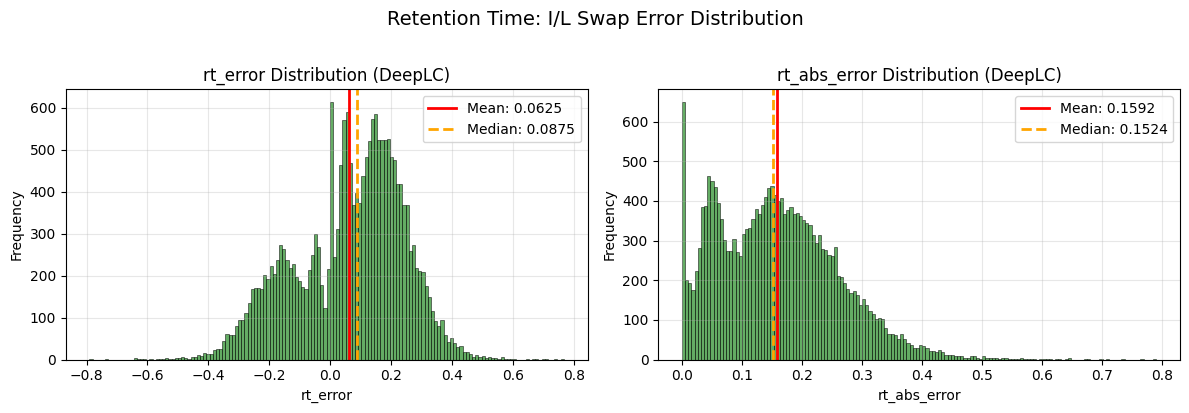

In [11]:
metrics_to_plot_rt = ["rt_error", "rt_abs_error"]
model_name_rt = "DeepLC"

fig, axes = plt.subplots(1, len(metrics_to_plot_rt), figsize=(12, 4))

for idx, metric in enumerate(metrics_to_plot_rt):
    ax = axes[idx]
    values = peptides_predictions_rt[metric].dropna()

    # Histogram
    ax.hist(
        values, bins=150, alpha=0.7, color="forestgreen", edgecolor="black", linewidth=0.5
    )

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(
        mean_val, color="red", linestyle="-", linewidth=2, label=f"Mean: {mean_val:.4f}"
    )
    ax.axvline(
        median_val,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Median: {median_val:.4f}",
    )

    ax.set_xlabel(f"{metric}")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{metric} Distribution ({model_name_rt})")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Retention Time: I/L Swap Error Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Create unique ID for each peptide sequence + charge combination
peptides_predictions["seq_charge"] = (
    peptides_predictions["peptide_sequences"]
    + "/"
    + peptides_predictions["precursor_charges"].astype(str)
)
unique_combinations = peptides_predictions["seq_charge"].unique()
seq_charge_to_id = {combo: i for i, combo in enumerate(unique_combinations)}

peptides_predictions["ID"] = peptides_predictions["seq_charge"].map(seq_charge_to_id)

# Create the same ID column for switched predictions based on original peptide mapping
peptides_switch_predictions["seq_charge"] = (
    peptides_switch_predictions["peptide_sequences"]
    + "/"
    + peptides_switch_predictions["precursor_charges"].astype(str)
)

# Map switched sequences back to original IDs (switched peptide -> original peptide -> ID)
# Note: switched_to_orig is defined earlier in the CCS ID creation cell
peptides_switch_predictions["orig_seq_charge"] = peptides_switch_predictions.apply(
    lambda row: switched_to_orig.get(row["peptide_sequences"], row["peptide_sequences"])
    + "/"
    + str(row["precursor_charges"]),
    axis=1,
)
peptides_switch_predictions["ID"] = peptides_switch_predictions["orig_seq_charge"].map(seq_charge_to_id)

print(f"Unique peptide+charge combinations: {len(unique_combinations)}")
print(f"peptides_predictions IDs: {peptides_predictions['ID'].nunique()}")
print(f"peptides_switch_predictions IDs: {peptides_switch_predictions['ID'].nunique()}")

Unique peptide+charge combinations: 20000
peptides_predictions IDs: 20000
peptides_switch_predictions IDs: 19999


In [13]:
score_df = metrics_comparison(peptides_predictions, peptides_switch_predictions)

In [14]:
peptides_predictions_ccs["error"] = (
    peptides_predictions_ccs["ccs"] - peptides_switch_predictions_ccs["ccs"]
)
peptides_predictions_ccs["abs_error"] = (
    peptides_predictions_ccs["ccs"] - peptides_switch_predictions_ccs["ccs"]
).abs()

In [15]:
metrics_to_plot = ["mse", "spectral_angle"]
model_name = "Prosit"

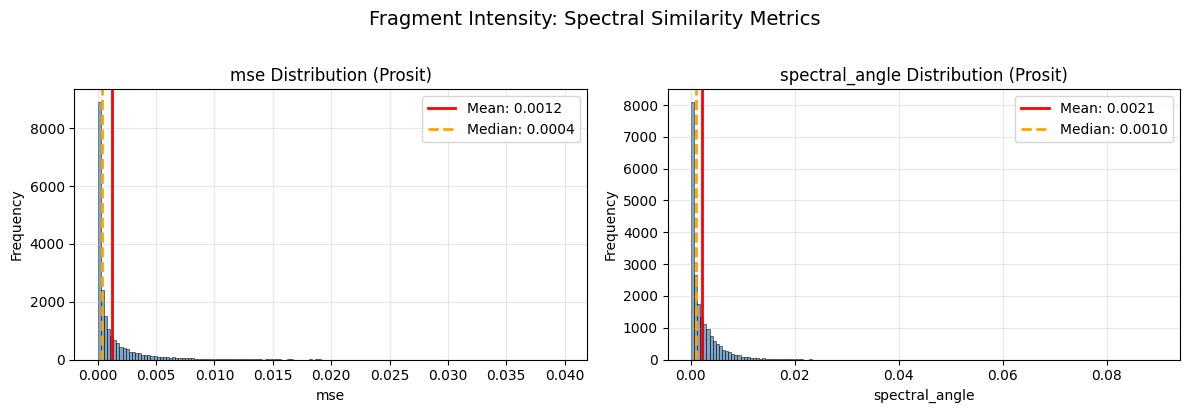

In [16]:
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(12, 4))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = score_df[metric].dropna()

    # Histogram
    ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')

    ax.set_xlabel(f"{metric}")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{metric} Distribution ({model_name})")
    if metric == "dot_product":
        ax.legend(loc="upper left")
    else:    
        ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Fragment Intensity: Spectral Similarity Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
metrics_to_plot = ["error", "abs_error"]
model_name = "AlphaPeptDeep"

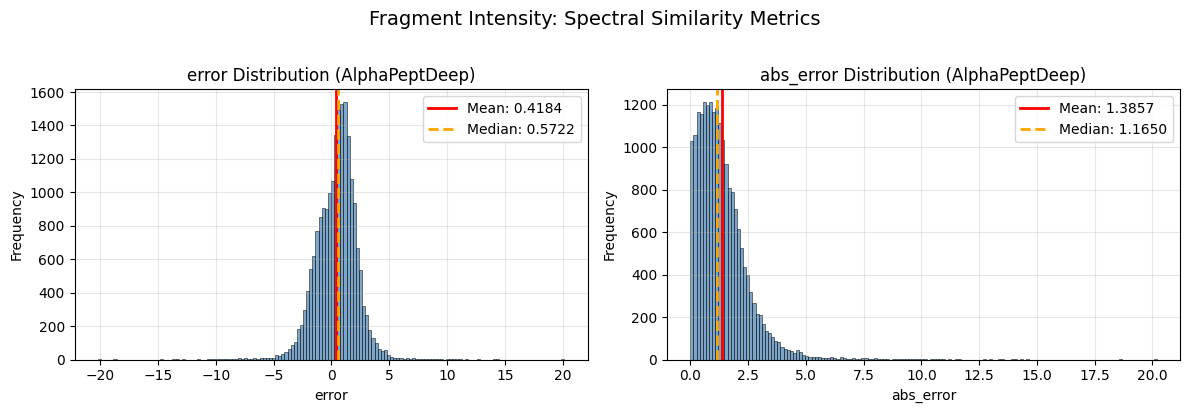

In [18]:
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(12, 4))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = peptides_predictions_ccs [metric].dropna()

    # Histogram
    ax.hist(
        values, bins=150, alpha=0.7, color="steelblue", edgecolor="black", linewidth=0.5
    )

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(
        mean_val, color="red", linestyle="-", linewidth=2, label=f"Mean: {mean_val:.4f}"
    )
    ax.axvline(
        median_val,
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Median: {median_val:.4f}",
    )

    ax.set_xlabel(f"{metric}")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{metric} Distribution ({model_name})")
    if metric == "dot_product":
        ax.legend(loc="upper left")
    else:
        ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Fragment Intensity: Spectral Similarity Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

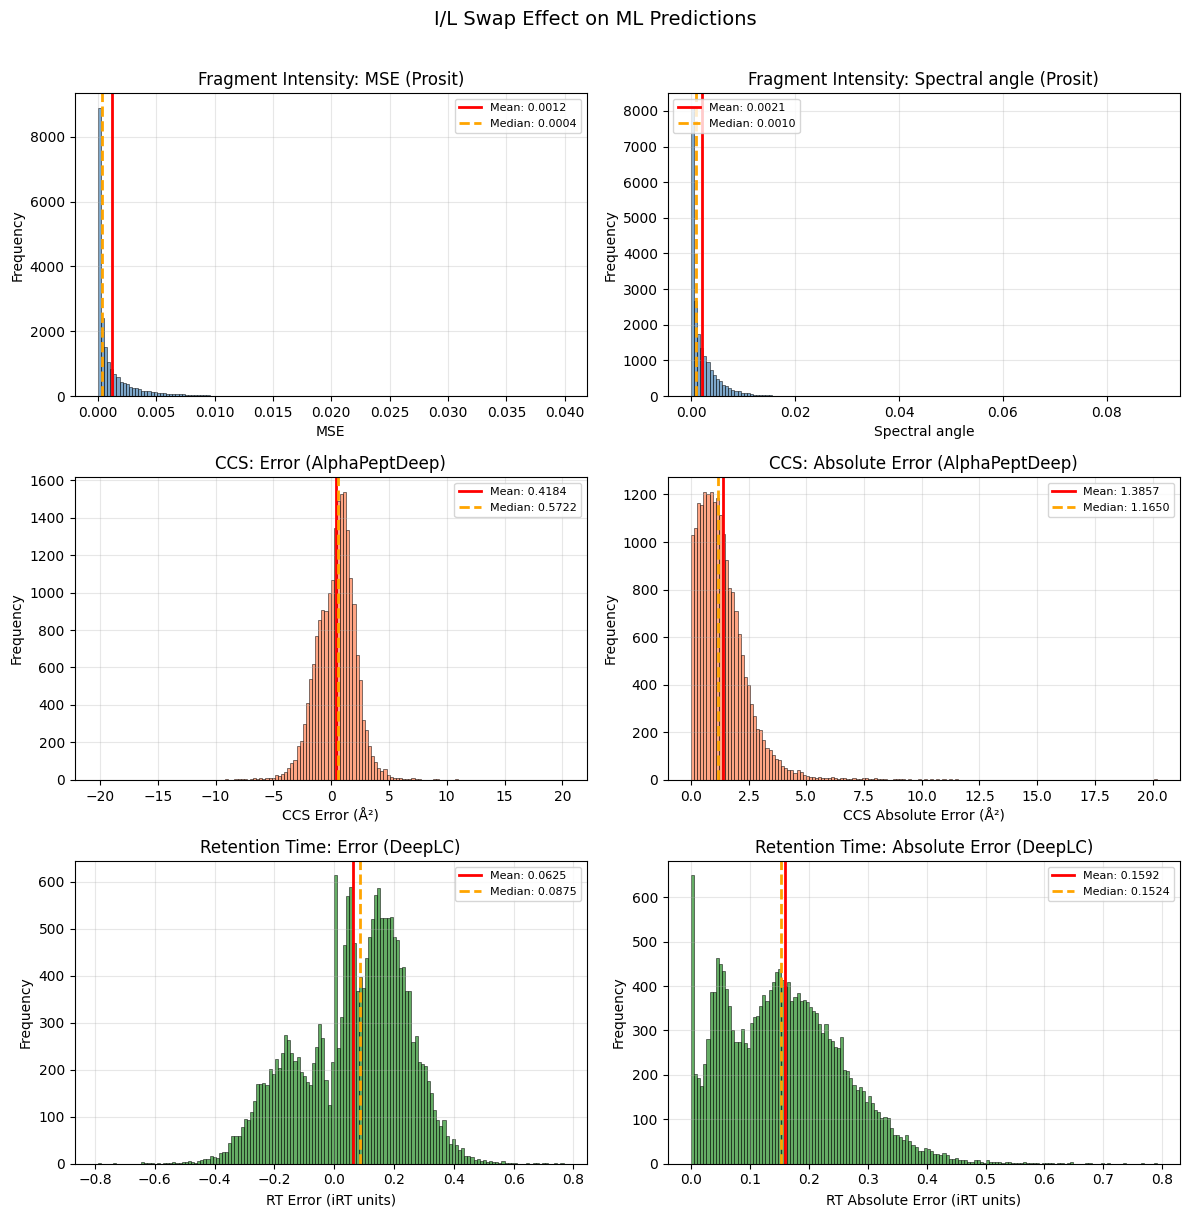

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Row 1: Fragment Intensity Metrics
# MSE
ax = axes[0, 0]
values = score_df["mse"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("MSE")
ax.set_ylabel("Frequency")
ax.set_title("Fragment Intensity: MSE (Prosit)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Spectral angle
ax = axes[0, 1]
values = score_df["spectral_angle"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("Spectral angle")
ax.set_ylabel("Frequency")
ax.set_title("Fragment Intensity: Spectral angle (Prosit)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Row 2: CCS Metrics
# CCS Error
ax = axes[1, 0]
values = peptides_predictions_ccs["error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("CCS Error (Å²)")
ax.set_ylabel("Frequency")
ax.set_title("CCS: Error (AlphaPeptDeep)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# CCS Absolute Error
ax = axes[1, 1]
values = peptides_predictions_ccs["abs_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("CCS Absolute Error (Å²)")
ax.set_ylabel("Frequency")
ax.set_title("CCS: Absolute Error (AlphaPeptDeep)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Row 3: Retention Time Metrics
# RT Error
ax = axes[2, 0]
values = peptides_predictions_rt["rt_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='forestgreen', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("RT Error (iRT units)")
ax.set_ylabel("Frequency")
ax.set_title("Retention Time: Error (DeepLC)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# RT Absolute Error
ax = axes[2, 1]
values = peptides_predictions_rt["rt_abs_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='forestgreen', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("RT Absolute Error (iRT units)")
ax.set_ylabel("Frequency")
ax.set_title("Retention Time: Absolute Error (DeepLC)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("I/L Swap Effect on ML Predictions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../temp_data/combined_il_swap_figure.png", dpi=300, bbox_inches='tight')
plt.show()

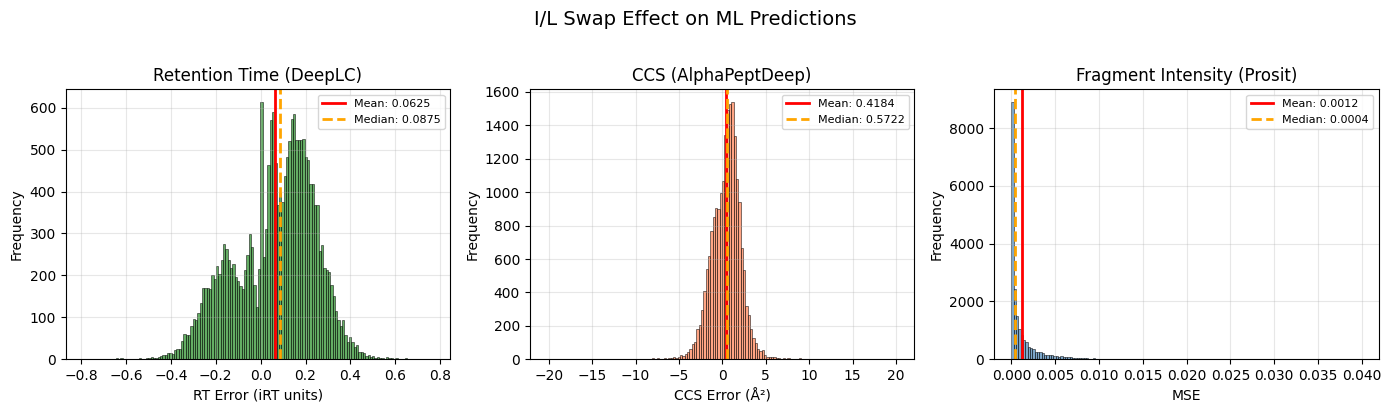

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Fragment Intensity: MSE
ax = axes[2]
values = score_df["mse"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("MSE")
ax.set_ylabel("Frequency")
ax.set_title("Fragment Intensity (Prosit)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# CCS: Error
ax = axes[1]
values = peptides_predictions_ccs["error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("CCS Error (Å²)")
ax.set_ylabel("Frequency")
ax.set_title("CCS (AlphaPeptDeep)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Retention Time: Error
ax = axes[0]
values = peptides_predictions_rt["rt_error"].dropna()
ax.hist(values, bins=150, alpha=0.7, color='forestgreen', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("RT Error (iRT units)")
ax.set_ylabel("Frequency")
ax.set_title("Retention Time (DeepLC)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("I/L Swap Effect on ML Predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../temp_data/simplified_il_swap_figure.png", dpi=300, bbox_inches='tight')
plt.show()